In [1]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import seaborn as sns
from programmable_cubes_UDP import ProgrammableCubes
from programmable_cubes_UDP import programmable_cubes_UDP
import numpy as np

In [2]:
# load the start configuration
DATA_TYPE = "Initial"
#DATA_TYPE = "Target"

configuration = np.load(f'./data/ISS/{DATA_TYPE}_Config.npy')
types = np.load(f"./data/ISS/{DATA_TYPE}_Cube_Types.npy")

# Create the cube ensemble with an initial cube configuration.
cubes = ProgrammableCubes(configuration)


In [7]:
configuration

array([[-1,  3,  0],
       [ 7,  2,  5],
       [ 9,  5,  5],
       [ 1,  4,  6],
       [ 4,  5,  5],
       [12,  3,  2],
       [ 4,  6,  5],
       [ 3,  4,  5],
       [ 0,  6,  4],
       [ 8,  5,  5],
       [ 7, -2, -1],
       [ 7, -1, -2],
       [ 9,  7,  7],
       [ 8,  3, -1],
       [ 2,  3,  5],
       [12,  6,  2],
       [ 4,  3,  2],
       [ 0,  8,  2],
       [ 5,  1,  5],
       [ 9,  7,  6],
       [ 7,  3, -1],
       [ 9,  5,  3],
       [ 0,  2,  1],
       [ 3,  3,  1],
       [ 8,  1, -2],
       [11,  3,  4],
       [-1,  0,  1],
       [ 5,  5,  6],
       [12,  6,  1],
       [ 6,  5,  5],
       [ 8,  7,  5],
       [ 8,  3,  2],
       [ 0,  1,  1],
       [ 8,  3,  1],
       [10,  7,  7],
       [ 9,  4,  4],
       [ 5,  5,  7],
       [ 7,  5,  6],
       [ 7,  4,  3],
       [11,  7,  1],
       [ 1,  3, -1],
       [ 0,  4,  5],
       [ 3,  7,  5],
       [ 5,  1,  4],
       [11,  6,  2],
       [ 0,  6,  2],
       [ 8,  2, -2],
       [ 6,  

(148, 3)

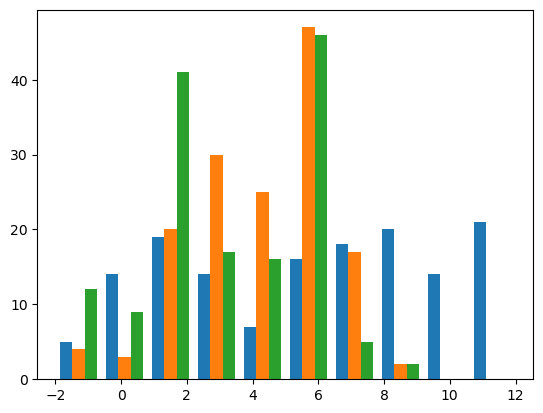

In [4]:
plt.hist(configuration)
configuration.shape

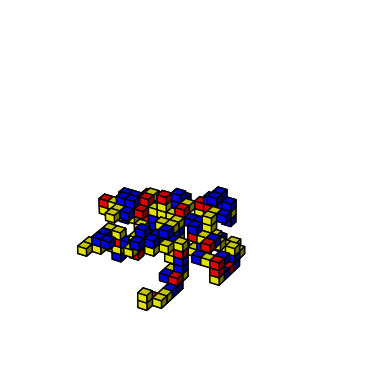

In [5]:


plt.rcParams['savefig.bbox'] = 'tight'

fig = plt.figure(figsize=(plt.figaspect(1)))
ax = fig.add_subplot(1, 1, 1, projection='3d')
#sns.despine(ax=ax, bottom=True,top=True,left=True,right=True)
ln, = ax.plot3D([0], [0], [0])
ax._axis3don = False
ax.set_facecolor('white')

SHIFT = np.array([2,2,2])
voxels = np.zeros(shape=(20,20,20))
colors = np.empty(shape=voxels.shape, dtype=object)
AC = ["yellow","red","blue","black"]
#lower_bounds = min(voxels)
for v,t in zip(configuration,types):
    #v = v -lower_bounds
    voxels[v[0]+SHIFT[0],v[1]+SHIFT[1],v[2]+SHIFT[2]] = True
    colors[v[0]+SHIFT[0],v[1]+SHIFT[1],v[2]+SHIFT[2]] = AC[t]

ax.voxels(voxels, facecolors = colors, edgecolors = 'k', alpha=1)
plt.show()
#from IPython.display import HTML
#HTML(fig.to_jshtml())

[np.float64(1.439749608725172e-06)]


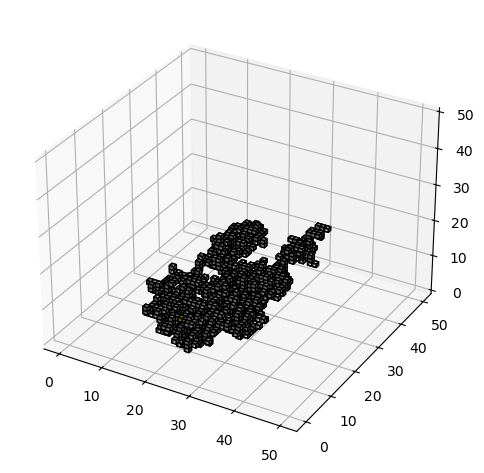

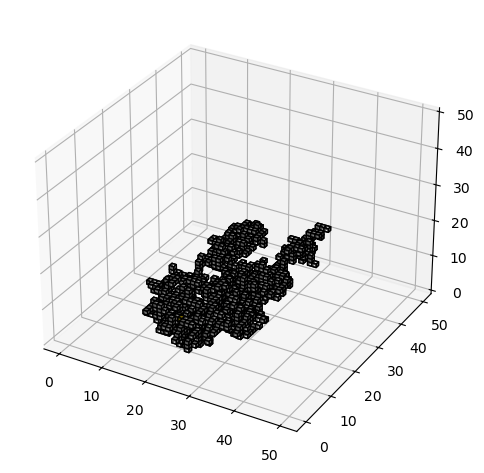

In [6]:
udp = programmable_cubes_UDP('Enterprise')

print(udp.fitness(np.array([0,4,-1])))
udp.plot("ensemble",[0,1,2])
def create_random_chromosome():
    chrom = []
    for i in range(1000):
        # select a cube randomly
        cube_id = np.random.randint(148)
        # select a maneuver randomly
        move = np.random.randint(6)
        
        # add command to chromosome
        chrom += [cube_id, move]
    # chromosome always ends with -1
    chrom += [-1]
    return np.array(chrom)

# create a random chromosome
chromosome = create_random_chromosome()
udp.fitness(chromosome)
udp.plot("ensemble",[0,1,2])
